# Zadanie domowe 2
### Autor: Kacper Łączyński

Poniżej przygotowałem dane do dalszej pracy, czyli zaimportowałem je, sprawdziłem ponownie czy występują braki danych oraz policzyłem logarytmiczne stopy zwrotu.

In [4]:
import yfinance as yf
import pandas as pd

pd.reset_option('display.float_format')

tickers = ['PKO.WA', 'PEO.WA', 'SPL.WA', 'MBK.WA', 'ALR.WA']

dane_surowe = yf.download(tickers, start="2024-04-10", end="2026-04-11", threads=False)

ceny_zamkniecia = dane_surowe['Close']

display(ceny_zamkniecia.head())

[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
Date,,,,,
2024-04-10,85.276596,711.799988,152.909363,53.144836,447.889984
2024-04-11,82.086800,695.400024,148.487198,51.602093,432.728302
2024-04-12,81.158127,687.200012,146.418106,51.247437,426.849213
2024-04-15,81.602272,683.799988,147.635208,51.584358,429.479340
2024-04-16,80.689743,670.599976,143.172485,49.527370,419.887207


In [11]:
import pandas as pd
import numpy as np

print("1. Brakujące dane przed czyszczeniem:")
print(ceny_zamkniecia.isnull().sum())

# 2. SPRAWDZENIE SPÓJNOŚCI DAT
print("\n2. Spójność dat kalendarza sesyjnego:")
print(f"Data początkowa: {ceny_zamkniecia.index.min().date()}")
print(f"Data końcowa: {ceny_zamkniecia.index.max().date()}")
print(f"Liczba pobranych dni sesyjnych ogółem: {len(ceny_zamkniecia)}\n")

# Liczymy proste stopy zwrotu
stopy_proste = ceny_zamkniecia.pct_change().dropna()
stopy_proste_250_dni = stopy_proste.tail(250)

print(f"Liczba danych (ostatnie 250 dni sesyjnych): {len(stopy_proste_250_dni)}")
display(stopy_proste_250_dni.head())

1. Brakujące dane przed czyszczeniem:
Ticker
ALR.WA    0
MBK.WA    0
PEO.WA    0
PKO.WA    0
SPL.WA    0
dtype: int64

2. Spójność dat kalendarza sesyjnego:
Data początkowa: 2024-04-10
Data końcowa: 2026-04-10
Liczba pobranych dni sesyjnych ogółem: 497

Liczba danych (ostatnie 250 dni sesyjnych): 250


Ticker,ALR.WA,MBK.WA,PEO.WA,PKO.WA,SPL.WA
Date,,,,,
2025-04-08,0.016813,0.028652,0.038935,0.039433,0.065302
2025-04-09,-0.026575,-0.033094,-0.035234,-0.043568,-0.041507
2025-04-10,0.058140,0.055904,0.091633,0.061977,0.064555
2025-04-11,0.001911,-0.004862,0.003650,-0.028888,-0.016949
2025-04-14,0.034812,0.044517,0.031515,0.030349,0.038697


In [ ]:
import numpy as np
import pandas as pd

kolumny = stopy_proste_250_dni.columns
print(f"Kolejność spółek do przypisania wag to: {list(kolumny)}\n")

# Ziarno losowości dla powtarzalności wyników
np.random.seed(194)

# Portfel 1: Równe wagi (po 20% dla każdej z 5 spółek)
wagi_rowne = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Portfel 2: Losowe wagi wygenerowane przez komputer
surowe_wagi = np.random.random(5)             
wagi_losowe = surowe_wagi / surowe_wagi.sum() 

print(f"Wylosowane wagi: {np.round(wagi_losowe, 4)}")
print(f"Suma losowych wag wynosi: {wagi_losowe.sum()}\n")

# ---- OBLICZENIE ZWROTÓW PORTFELA ----
# 1. Obliczamy dzienne stopy zwrotu CAŁEGO portfela używając stóp prostych
zwroty_proste_portfel_rowny = stopy_proste_250_dni.dot(wagi_rowne)
zwroty_proste_portfel_losowy = stopy_proste_250_dni.dot(wagi_losowe)

# 2. Zamieniamy policzone stopy portfela na logarytmiczne (na potrzeby obliczania VaR/ES)
zwroty_portfel_rowny = np.log(1 + zwroty_proste_portfel_rowny)
zwroty_portfel_losowy = np.log(1 + zwroty_proste_portfel_losowy)

print("Podgląd logarytmicznych stóp zwrotu portfela równoważonego:")
print(zwroty_portfel_rowny.head())

Kolejność spółek do przypisania wag to: ['ALR.WA', 'MBK.WA', 'PEO.WA', 'PKO.WA', 'SPL.WA']

Wylosowane wagi: [0.2778 0.2063 0.1644 0.1575 0.1939]
Suma losowych wag wynosi: 1.0

Podgląd logarytmicznych stóp zwrotu portfela równoważonego:
Date
2025-04-08    0.037129
2025-04-09   -0.036659
2025-04-10    0.064328
2025-04-11   -0.009069
2025-04-14    0.035346
dtype: float64


### Metodyka alokacji kapitału i agregacji stóp zwrotu

Do wyznaczenia wag w portfelu losowym zastosowałem generator pseudolosowy z rozkładu jednostajnego (`np.random.random`), uzyskując w ten sposób 5 początkowych wartości. Następnie znormalizowałem je, dzieląc każdą z nich przez ich łączną sumę. Taki zabieg zagwarantował mi pełną, poprawną alokację kapitału (wagi sumują się dokładnie do 1, czyli 100%). Aby dodatkowo zapewnić pełną replikowalność moich wyników przy każdym ponownym uruchomieniu środowiska, zdefiniowałem ziarno losowości (`seed`) na poziomie 194.

**Metodyka agregacji stóp zwrotu:**
Zgodnie z prawami matematyki finansowej, logarytmiczne stopy zwrotu nie są addytywne w przekroju przestrzennym (przy łączeniu aktywów w portfel). Z tego względu, do prawidłowego wyliczenia zachowania całego koszyka wyznaczyłem najpierw **proste stopy zwrotu** dla każdej z badanych spółek. To na ich podstawie obliczyłem średnią ważoną, uzyskując precyzyjny dzienny zwrot z portfela. Dopiero ten zagregowany wektor przekształciłem na **logarytmiczną stopę zwrotu**. Zastosowanie tego konkretnego podejścia gwarantuje, że mój model w 100% poprawnie odzwierciedla rzeczywiste zachowanie kapitału, a finalne szeregi czasowe są idealnie przystosowane do estymacji modeli ryzyka (VaR).

In [13]:
import numpy as np
import pandas as pd

def oblicz_var(zwroty):
    log_perc_95 = np.percentile(zwroty, 5)
    log_perc_99 = np.percentile(zwroty, 1)

    #Zamiana wyników na procenty
    var_hist_95 = 1 - np.exp(log_perc_95)
    var_hist_99 = 1 - np.exp(log_perc_99)
    
    mu = np.mean(zwroty)
    sigma = np.std(zwroty, ddof=1)

    log_param_95 = mu - 1.65 * sigma
    log_param_99 = mu - 2.33 * sigma

    #Zamiana wyników na procenty
    var_param_95 = 1 - np.exp(log_param_95)
    var_param_99 = 1 - np.exp(log_param_99)
    
    return [var_hist_95, var_param_95, var_hist_99, var_param_99]

wyniki_rowny = oblicz_var(zwroty_portfel_rowny)
wyniki_losowy = oblicz_var(zwroty_portfel_losowy)

tabela_var = pd.DataFrame({
    'Metoda kalkulacji VaR': ['Historyczny (95%)', 'Parametryczny (95%)', 'Historyczny (99%)', 'Parametryczny (99%)'],
    'Portfel Równoważony': wyniki_rowny,
    'Portfel Losowy': wyniki_losowy
})

pd.options.display.float_format = '{:.2%}'.format
print("\n--- WYNIKI VALUE AT RISK (VaR) ---")
display(tabela_var)


--- WYNIKI VALUE AT RISK (VaR) ---


,Metoda kalkulacji VaR,Portfel Równoważony,Portfel Losowy
0,Historyczny (95%),2.45%,2.45%
1,Parametryczny (95%),2.93%,2.94%
2,Historyczny (99%),3.75%,3.80%
3,Parametryczny (99%),4.19%,4.21%


### Podsumowanie Raportu Ryzyka

#### 1. Który portfel jest mniej ryzykowny?
Na podstawie wygenerowanej tabeli wyników wnioskuję, że **różnica w profilu ryzyka obu portfeli jest marginalna i ekonomicznie pomijalna**. 

Analizując konkretne wartości, zauważam, że dla poziomu ufności 95% w metodzie historycznej wyniki są identyczne (2,45%). Z kolei dla ufności 99% portfel równoważony wykazuje ryzyko niższe zaledwie o 0,05 p.p. w metodzie historycznej (3,75% vs 3,80%) i o 0,02 p.p. w parametrycznej (4,19% vs 4,21%). 

Z perspektywy zarządzania ryzykiem, różnice rzędu setnych części procenta traktuję jako szum statystyczny. Fakt ten jest bezpośrednią konsekwencją mojego wniosku z Zadania 1 – badane banki są ze sobą ekstremalnie silnie skorelowane. Mimo że w portfelu losowym algorytm przydzielił wyższą wagę dla Alior Banku (ok. 28%), to zjawisko to nie zaburzyło ogólnego ryzyka portfela. Wszystkie te instrumenty reagują na niemal identyczne szoki makroekonomiczne, przez co oba portfele niosą ze sobą dokładnie takie samo ryzyko systemowe.

#### 2. Porównanie metod: Dlaczego VaR parametryczny jest wyższy?
Zestawiając obie metody, zaobserwowałem istotną prawidłowość: **metoda parametryczna wygenerowała zauważalnie wyższe estymacje potencjalnej straty** w stosunku do metody historycznej (np. 4,19% vs 3,75% dla portfela równoważonego przy 99%). Choć w finansach często zakłada się, że to metoda historyczna wskaże wyższe ryzyko ze względu na rynkowe "grube ogony" (nieprzewidziane krachy), w tym specyficznym przypadku zaszło zjawisko odwrotne. 

Ten nieintuicyjny wynik potrafię merytorycznie uzasadnić dwoma czynnikami:
1. **Asymetria trendu rynkowego:** W badanym oknie 250 dni polski sektor bankowy znajdował się w wyraźnym trendzie wzrostowym (hossa), bez głębokich historycznych załamań. Metoda historyczna, bazując stricte na zrealizowanych zwrotach, odzwierciedla ten łagodny, "spokojny" lewy ogon rozkładu.
2. **Pułapka wariancji w rozkładzie normalnym:** Silne, pozytywne stopy zwrotu wygenerowane podczas wzrostów siłą rzeczy zwiększyły odchylenie standardowe (zmienność instrumentów). Metoda parametryczna wymusza na danych idealnie symetryczny rozkład normalny. W konsekwencji, algorytm "wziął" tę wysoką historyczną zmienność wywołaną przez *zyski* i w sposób ślepy, symetrycznie przeniósł ją na lewą stronę wykresu, kreując wysoki szacunek potencjalnych *strat*.

Z racji powyższego uważam, że w środowisku silnego trendu wzrostowego metoda parametryczna przeszacowuje ryzyko spadków, narzucając rynkowi sztuczną symetrię. Metoda historyczna znacznie lepiej oddaje faktyczny obraz stabilności tego sektora w ostatnim roku.

# Wizualizacja poszczególnych VaR dla obu metod:

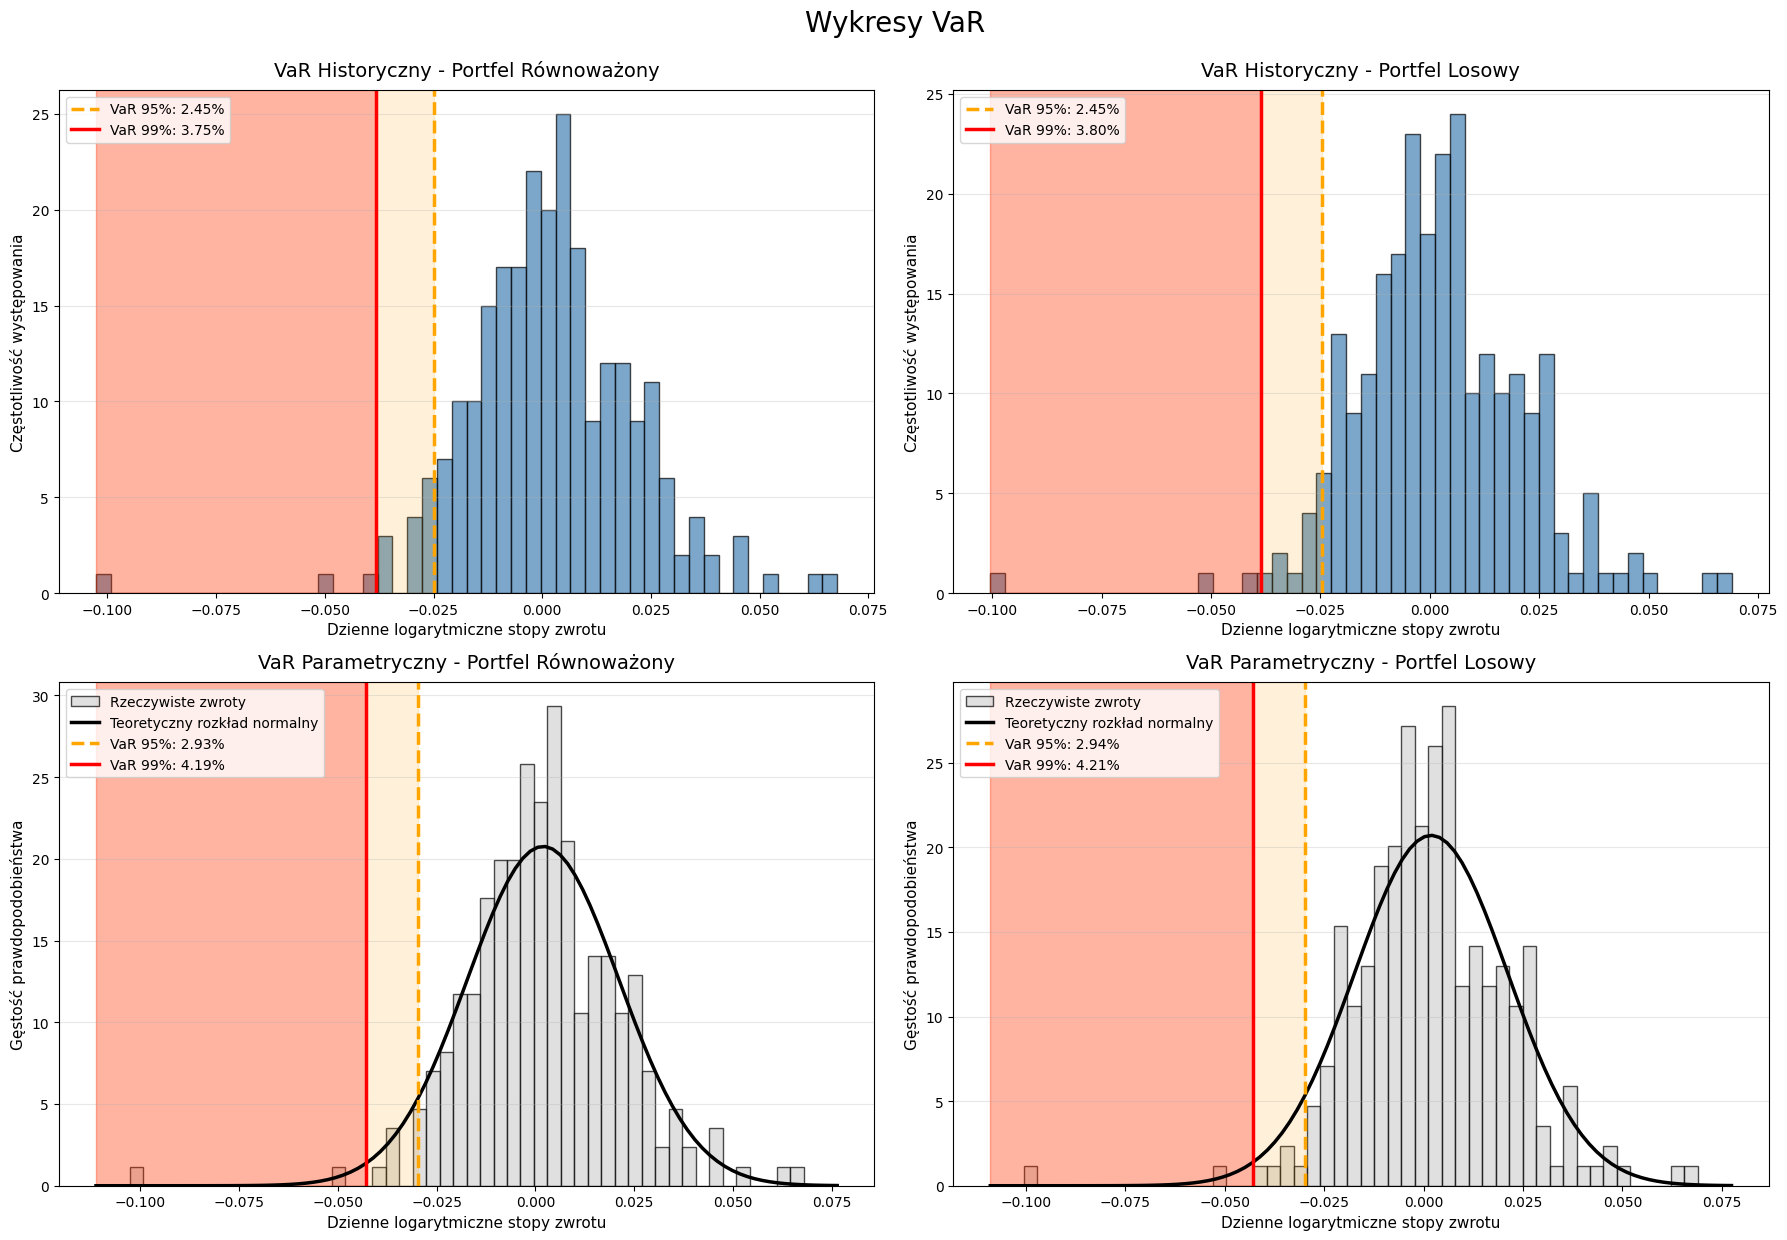

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

def rysuj_wykres_historyczny(ax, zwroty, tytul):
    odciecie_95 = np.percentile(zwroty, 5)
    odciecie_99 = np.percentile(zwroty, 1)
    
    proc_95 = 1 - np.exp(odciecie_95)
    proc_99 = 1 - np.exp(odciecie_99)

    ax.hist(zwroty, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    
    ax.axvline(x=odciecie_95, color='orange', linestyle='--', linewidth=2.5, label=f'VaR 95%: {proc_95:.2%}')
    ax.axvline(x=odciecie_99, color='red', linestyle='-', linewidth=2.5, label=f'VaR 99%: {proc_99:.2%}')
    
    ax.axvspan(zwroty.min(), odciecie_95, color='orange', alpha=0.15)
    ax.axvspan(zwroty.min(), odciecie_99, color='red', alpha=0.25)

    ax.set_title(tytul, fontsize=14, pad=10)
    ax.set_xlabel('Dzienne logarytmiczne stopy zwrotu', fontsize=11)
    ax.set_ylabel('Częstotliwość występowania', fontsize=11)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3)


def rysuj_wykres_parametryczny(ax, zwroty, tytul):
    mu = np.mean(zwroty)
    sigma = np.std(zwroty, ddof=1)
    
    odciecie_95 = mu - 1.65 * sigma
    odciecie_99 = mu - 2.33 * sigma
    
    proc_95 = 1 - np.exp(odciecie_95)
    proc_99 = 1 - np.exp(odciecie_99)

    ax.hist(zwroty, bins=50, density=True, color='lightgray', edgecolor='black', alpha=0.7, label='Rzeczywiste zwroty')

    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    ax.plot(x, p, 'k', linewidth=2.5, label='Teoretyczny rozkład normalny')

    ax.axvline(x=odciecie_95, color='orange', linestyle='--', linewidth=2.5, label=f'VaR 95%: {proc_95:.2%}')
    ax.axvline(x=odciecie_99, color='red', linestyle='-', linewidth=2.5, label=f'VaR 99%: {proc_99:.2%}')
    
    ax.axvspan(xmin, odciecie_95, color='orange', alpha=0.15)
    ax.axvspan(xmin, odciecie_99, color='red', alpha=0.25)

    ax.set_title(tytul, fontsize=14, pad=10)
    ax.set_xlabel('Dzienne logarytmiczne stopy zwrotu', fontsize=11)
    ax.set_ylabel('Gęstość prawdopodobieństwa', fontsize=11)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3)


rysuj_wykres_historyczny(axes[0, 0], zwroty_portfel_rowny, 'VaR Historyczny - Portfel Równoważony')
rysuj_wykres_historyczny(axes[0, 1], zwroty_portfel_losowy, 'VaR Historyczny - Portfel Losowy')


rysuj_wykres_parametryczny(axes[1, 0], zwroty_portfel_rowny, 'VaR Parametryczny - Portfel Równoważony')
rysuj_wykres_parametryczny(axes[1, 1], zwroty_portfel_losowy, 'VaR Parametryczny - Portfel Losowy')

plt.tight_layout()
fig.suptitle('Wykresy VaR', fontsize=20, y=1.03)
plt.show()